In [22]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential


from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image





In [30]:
print(tf.__version__)
print(np.__version__)
print(PIL.__version__)

2.4.1
1.19.4
8.1.0


In [31]:
!pip list

Package                Version
---------------------- -------------------
absl-py                0.11.0
argon2-cffi            20.1.0
astunparse             1.6.3
async-generator        1.10
attrs                  20.3.0
backcall               0.2.0
bleach                 3.2.1
cachetools             4.2.0
certifi                2020.12.5
cffi                   1.14.4
chardet                4.0.0
colorama               0.4.4
cycler                 0.10.0
decorator              4.4.2
defusedxml             0.6.0
entrypoints            0.3
flatbuffers            1.12
gast                   0.3.3
google-auth            1.24.0
google-auth-oauthlib   0.4.2
google-pasta           0.2.0
grpcio                 1.32.0
h5py                   2.10.0
idna                   2.10
importlib-metadata     2.0.0
imutils                0.5.3
ipykernel              5.3.4
ipython                7.19.0
ipython-genutils       0.2.0
ipywidgets             7.6.3
jedi                   0.18.0
Jinja2            

In [9]:
import pathlib
data_dir = "new_data"
data_dir = pathlib.Path(data_dir)

In [10]:
batch_size = 32
img_height = 180
img_width = 180

In [11]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 2357 files belonging to 9 classes.
Using 1886 files for training.


In [14]:
class_names = train_ds.class_names
print(class_names)

['actinic_keratosis', 'basal_cell_carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented_benign_keratosis', 'seborrheic_keratosis', 'squamous_cell_carcinoma', 'vascular_lesion']


In [15]:
num_classes = 9

model = Sequential([
  layers.experimental.preprocessing.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.load_weights('my_checkpoint.ckpt')


Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.convolutional.Conv2D object at 0x000001924B0FB3D0> and <tensorflow.python.keras.layers.pooling.MaxPooling2D object at 0x000001924B0FBB50>).

Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.convolutional.Conv2D object at 0x000001924B184520> and <tensorflow.python.keras.layers.pooling.MaxPooling2D object at 0x000001924B0FB280>).

Two checkpoint references resolved to different objects (<tensorflow.python.keras.layers.convolutional.Conv2D object at 0x000001924B184C40> and <tensorflow.python.keras.layers.pooling.MaxPooling2D object at 0x000001924B184F10>).


## Predict on new data

Note: Data augmentation and Dropout layers are inactive at inference time.

class actinic_keratosis, score: 0.00
class basal_cell_carcinoma, score: 0.00
class dermatofibroma, score: 0.00
class melanoma, score: 8.84
class nevus, score: 91.07
class pigmented_benign_keratosis, score: 0.05
class seborrheic_keratosis, score: 0.02
class squamous_cell_carcinoma, score: 0.00
class vascular_lesion, score: 0.02


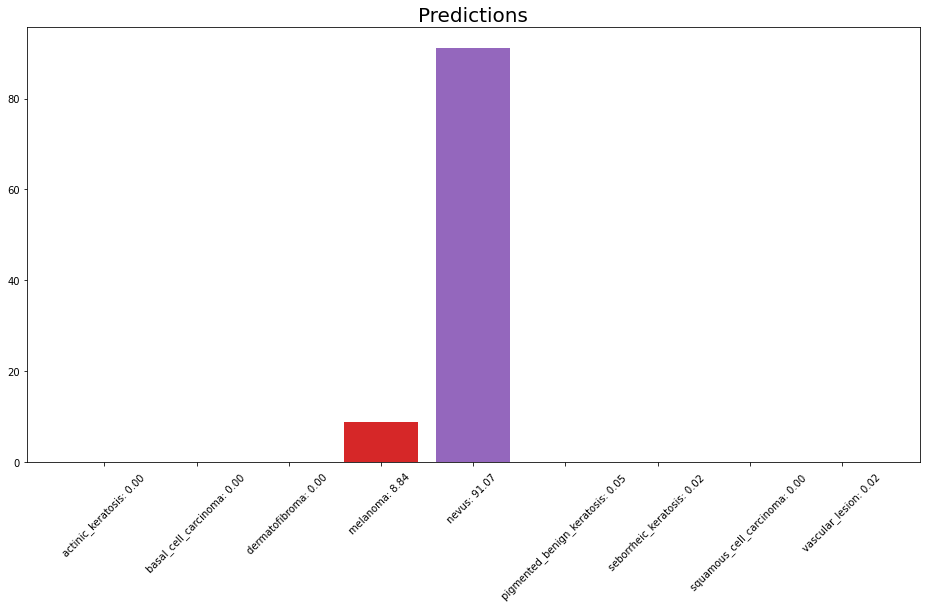

In [39]:
test_image_path = "ISIC_0000013.jpg"

img = keras.preprocessing.image.load_img(
    test_image_path, target_size=(img_height, img_width)
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array,batch_size = 2)
score = tf.nn.softmax(predictions[0])


plt.figure(figsize=(16,8))

for index in range(0,len(score)):
    prediction = score[index]
    prediction_score = 100 * np.max(prediction)
    print('class {}, score: {:.2f}'.format(class_names[index], prediction_score))
    plt.bar('{}: {:.2f} '.format(class_names[index], prediction_score),prediction_score) 

plt.title('Predictions', size = 20)
plt.xticks(size=10,rotation=45)
plt.yticks(size=10)

plt.savefig('savefig.png', bbox_inches='tight')
plt.show()


